In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/economic_master_dataset.csv")

df.head()

,Country Name,Country Code,Year,GDP,GDP_Growth,Inflation,Unemployment,Population,Exports
0,Africa Eastern and Southern,AFE,1991,2.769185e+11,-0.106034,17.678100,8.050809,320442961.0,18.440862
1,Australia,AUS,1991,3.264164e+11,-0.384631,3.176675,9.586000,17284036.0,16.006723
2,Austria,AUT,1991,1.731134e+11,3.441627,3.337427,3.420000,7754891.0,34.726507
3,Belgium,BEL,1991,2.105110e+11,1.833074,3.215311,6.984000,10004486.0,60.229655
4,Burkina Faso,BFA,1991,3.135046e+09,9.069984,2.162601,2.467000,9394632.0,10.447548


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6350 entries, 0 to 6349
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  6350 non-null   str    
 1   Country Code  6350 non-null   str    
 2   Year          6350 non-null   int64  
 3   GDP           6350 non-null   float64
 4   GDP_Growth    6350 non-null   float64
 5   Inflation     6350 non-null   float64
 6   Unemployment  6350 non-null   float64
 7   Population    6350 non-null   float64
 8   Exports       6350 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 446.6 KB


In [5]:
df.shape

(6350, 9)

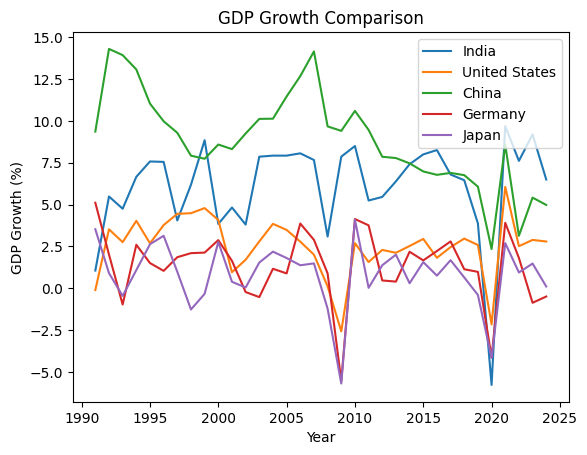

In [6]:
import matplotlib.pyplot as plt

countries = ["India", "United States", "China", "Germany","Japan"]

for country in countries:
    data = df[df["Country Name"] == country]
    plt.plot(data["Year"], data["GDP_Growth"], label=country)

plt.legend()
plt.title("GDP Growth Comparison")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.show()

China has rapid gdp growth in early 2000


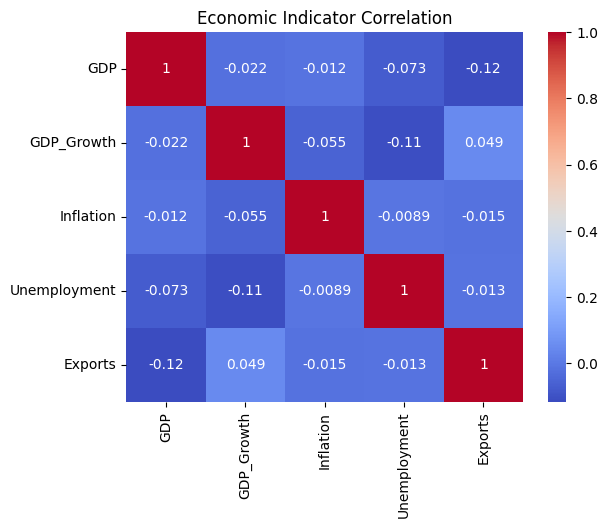

In [7]:
import seaborn as sns

corr = df[["GDP","GDP_Growth","Inflation","Unemployment","Exports"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Economic Indicator Correlation")
plt.show()

GDP negatively correlate with unemployment

inflation negatively correlate with gdp_growth


In [8]:
avg_gdp_growth = df.groupby("Country Name")["GDP_Growth"].mean().sort_values(ascending=False)

In [9]:
print(avg_gdp_growth)

Country Name
China                                          8.865510
Ethiopia                                       8.319006
Qatar                                          8.141656
Honduras                                       7.936015
East Asia & Pacific (excluding high income)    7.772709
                                                 ...   
Lebanon                                       -0.514119
Ukraine                                       -0.552348
Venezuela, RB                                 -2.587714
South Sudan                                   -4.925338
Afghanistan                                   -6.765792
Name: GDP_Growth, Length: 209, dtype: float64


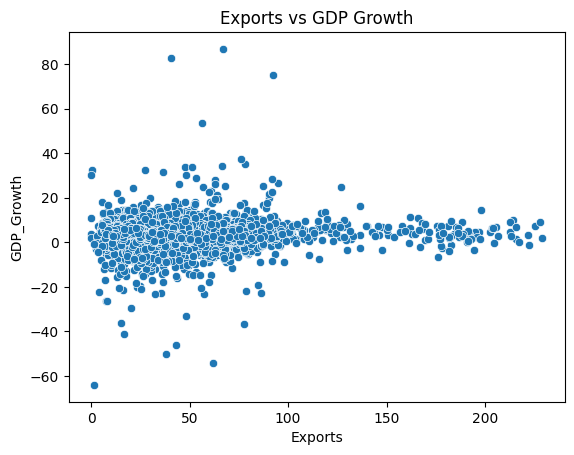

In [12]:
sns.scatterplot(data=df, x="Exports", y="GDP_Growth")

plt.title("Exports vs GDP Growth")
plt.show()